# T5-small Gram Regression (Seq2Seq)

Goal:
- Fine-tune `t5-small` to generate gram value text from `unit/size/name`.
- Compare with FastText + LightGBM baseline.

Input format:
- `unit: ... size: ... name: ...`

Target format:
- e.g. `"14.50"`

In [6]:
%pip install numpy pandas matplotlib scikit-learn transformers datasets evaluate sentencepiece torch accelerate tiktoken

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
DATA_PATH = Path('scrape/output_filled.json')
with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def to_input(r):
    unit = str(r.get('unit', '') or '').strip().lower()
    size = str(r.get('size', '') or '').strip().lower()
    name = str(r.get('name', '') or '').strip().lower()
    return f'unit: {unit} | size: {size} | name: {name}'

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({'input_text': to_input(r), 'label_text': f'{gram:.2f}', 'gram': gram})

df = pd.DataFrame(records)
print('usable rows:', len(df))
df.head()

usable rows: 18262


,input_text,label_text,gram
0,unit: tablespoon | size: | name: fresh mint leaf,2.00,2.0
1,unit: cup | size: | name: instant iced tea po...,200.00,200.0
2,unit: cup | size: | name: white sugar,200.00,200.0
3,unit: cup | size: | name: fat free half-and-half,240.00,240.0
4,unit: cup | size: | name: sugar,200.00,200.0


In [4]:
# Optional downsample for quick experiment
MAX_ROWS = 20000  # set None or larger for full run
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print('downsampled rows:', len(df))

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['input_text', 'label_text']])
val_ds = Dataset.from_pandas(val_df[['input_text', 'label_text']])

In [5]:
MODEL_NAME = 't5-small'
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

def preprocess(examples):
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)
collator = DataCollatorForSeq2Seq(tokenizer, model=model)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/14609 [00:00<?, ? examples/s]

Map:   0%|          | 0/3653 [00:00<?, ? examples/s]

In [6]:
args = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
)

trainer.train()

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,1.356485,1.256208
2,1.176137,1.109198
3,1.091553,1.016152
4,1.021163,0.972023
5,1.013038,0.956138


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/kyungmin/Desktop/Projects/food_chart_public/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2285, training_loss=1.1826711809087374, metrics={'train_runtime': 202.9257, 'train_samples_per_second': 359.959, 'train_steps_per_second': 11.26, 'total_flos': 425568813416448.0, 'train_loss': 1.1826711809087374, 'epoch': 5.0})

In [14]:
import torch

def parse_float(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs = val_df['input_text'].tolist()

# Keep model and inputs on the same device.
device = next(model.parameters()).device
model.eval()
enc = tokenizer(
    val_inputs,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    try:
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        # Some MPS runs can fail with placeholder storage errors.
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model = model.to('cpu')
        enc = {k: v.to('cpu') for k, v in enc.items()}
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

pred_vals = np.array([parse_float(x) for x in pred_texts], dtype=np.float64)
true_vals = val_df['gram'].values.astype(np.float64)

mask = ~np.isnan(pred_vals)
pred_ok = np.maximum(pred_vals[mask], 0)
true_ok = true_vals[mask]

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = mask.mean()

print(f'Parse success rate: {parse_rate:.4f}')
print(f'MAE: {mae:.4f} g')
print(f'MAPE: {mape:.2f}%')
print(f'Within 20%: {within20:.4f}')

Parse success rate: 1.0000
MAE: 55.1919 g
MAPE: 175.99%
Within 20%: 0.5809


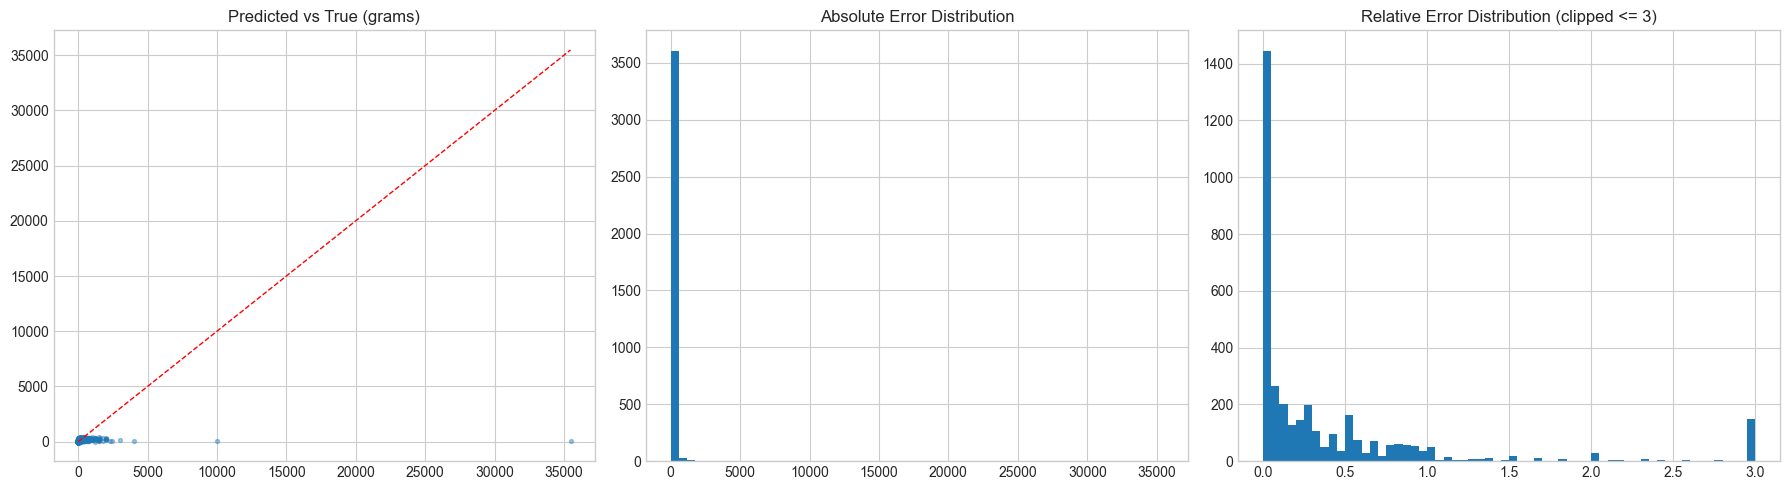

In [15]:
res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

In [13]:
# Deeper evaluation: robust metrics + gram-range metrics

eval_df = pd.DataFrame({
    'input_text': val_df.loc[mask, 'input_text'].values,
    'y_true': true_ok,
    'y_pred': pred_ok,
})
eval_df['abs_err'] = (eval_df['y_true'] - eval_df['y_pred']).abs()
eval_df['rel_err'] = eval_df['abs_err'] / np.maximum(eval_df['y_true'].abs(), 1e-8)

# Robust metrics (exclude top 1% largest true grams)
q99_true = eval_df['y_true'].quantile(0.99)
robust_df = eval_df[eval_df['y_true'] <= q99_true].copy()

mae_all = eval_df['abs_err'].mean()
mae_robust = robust_df['abs_err'].mean()
mape_all = eval_df['rel_err'].mean() * 100
mape_robust = robust_df['rel_err'].mean() * 100
within20_all = (eval_df['rel_err'] <= 0.2).mean()
within20_robust = (robust_df['rel_err'] <= 0.2).mean()

print('=== Overall vs Robust (exclude top 1% y_true) ===')
print(f'Overall MAE: {mae_all:.4f} g')
print(f'Robust  MAE: {mae_robust:.4f} g')
print(f'Overall MAPE: {mape_all:.2f}%')
print(f'Robust  MAPE: {mape_robust:.2f}%')
print(f'Overall Within 20%: {within20_all:.4f}')
print(f'Robust  Within 20%: {within20_robust:.4f}')

# Range metrics
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
eval_df['range_bin'] = pd.cut(eval_df['y_true'], bins=bins, labels=labels, include_lowest=True)

range_metrics = eval_df.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('\n=== Metrics by True Gram Range ===')
display(range_metrics)


=== Overall vs Robust (exclude top 1% y_true) ===
Overall MAE: 55.1919 g
Robust  MAE: 29.8048 g
Overall MAPE: 175.99%
Robust  MAPE: 176.87%
Overall Within 20%: 0.5809
Robust  Within 20%: 0.5867

=== Metrics by True Gram Range ===


,range_bin,count,mae_g,mape_pct,within20
0,0-50g,1841.0,14.729196,324.251084,0.522542
1,50-200g,1067.0,31.340675,29.034568,0.601687
2,200g+,745.0,189.340832,20.072994,0.695302


/var/folders/4m/h90ddv7j3fddt74yl61sg_5c0000gn/T/ipykernel_14087/2912496177.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=labels, showfliers=False)


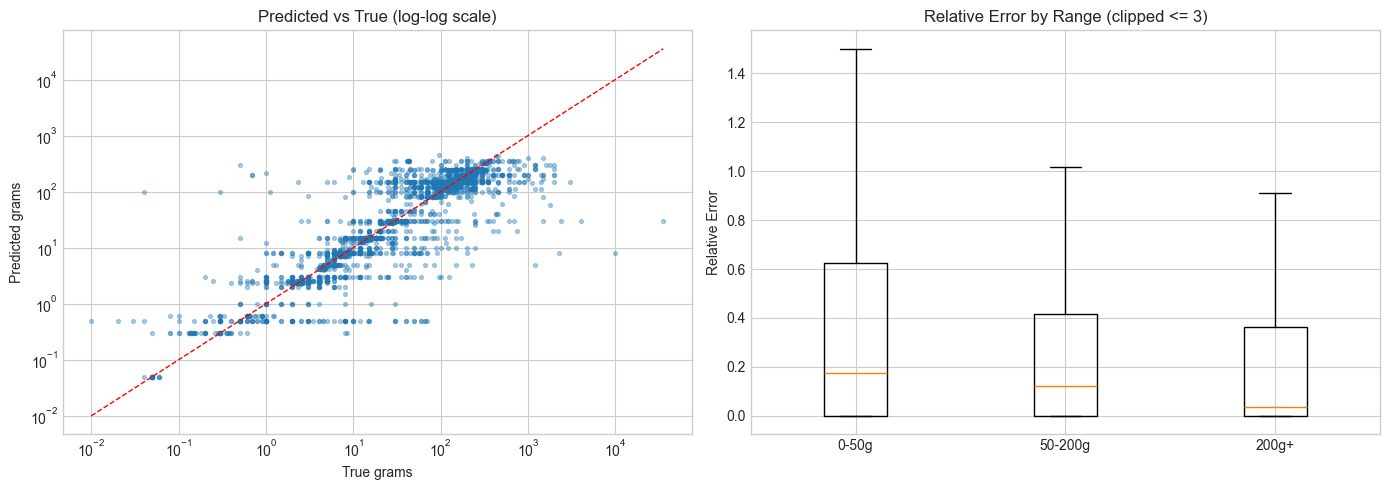

=== Top 20 Worst Absolute Error Samples ===


,y_true,y_pred,abs_err,rel_err,input_text
770,35478.0,30.0,35448.0,0.999154,unit: petainch * picoinch | size: | name: salt
2220,10000.0,8.0,9992.0,0.999200,unit: | size: | name: extra-large turkey bag
1178,4000.0,30.0,3970.0,0.992500,unit: | size: | name: heavy clay brick
743,3000.0,150.0,2850.0,0.950000,unit: | size: | name: whole salmon
2933,2400.0,30.0,2370.0,0.987500,unit: | size: | name: clay brick
1680,2268.0,8.0,2260.0,0.996473,unit: bag | size: | name: ice cube
3392,2000.0,150.0,1850.0,0.925000,unit: | size: small | name: underripe watermelon
925,2000.0,200.0,1800.0,0.900000,unit: | size: large | name: unripe papaya
547,2000.0,200.0,1800.0,0.900000,unit: | size: large | name: pineapple
670,2000.0,250.0,1750.0,0.875000,unit: | size: | name: point from whole smoke...


In [16]:
# Better diagnostics: log-scale scatter + worst-error examples

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale scatter (compresses very large grams)
x = np.clip(eval_df['y_true'].values, 1e-6, None)
y = np.clip(eval_df['y_pred'].values, 1e-6, None)
axes[0].scatter(x, y, s=8, alpha=0.35)
mn = min(x.min(), y.min())
mx = max(x.max(), y.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title('Predicted vs True (log-log scale)')
axes[0].set_xlabel('True grams')
axes[0].set_ylabel('Predicted grams')

# Relative error boxplot by range
box_data = [
    eval_df.loc[eval_df['range_bin'] == lb, 'rel_err'].clip(0, 3).values
    for lb in labels
]
axes[1].boxplot(box_data, labels=labels, showfliers=False)
axes[1].set_title('Relative Error by Range (clipped <= 3)')
axes[1].set_ylabel('Relative Error')

plt.tight_layout()
plt.show()

# Top worst cases for manual inspection
worst_n = 20
worst_df = eval_df.sort_values('abs_err', ascending=False).head(worst_n).copy()
print(f'=== Top {worst_n} Worst Absolute Error Samples ===')
display(worst_df[['y_true', 'y_pred', 'abs_err', 'rel_err', 'input_text']])


In [20]:
# Quick T5 inference cell (single/batch)
import torch
from pathlib import Path
from transformers import T5Tokenizer, T5ForConditionalGeneration

# 1) Load model/tokenizer if not already in memory
if 'model' not in globals() or 'tokenizer' not in globals():
    candidate_dirs = [
        Path('artifacts/t5_small_grams_final'),
        Path('artifacts/t5_small_grams'),
    ]
    load_dir = None
    for d in candidate_dirs:
        if d.exists():
            load_dir = d
            break
    if load_dir is None:
        raise FileNotFoundError('No saved model found. Train first or save model to artifacts/t5_small_grams_final')

    print(f'Loading model from: {load_dir}')
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

# 2) Device setup
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Inference device:', device)

# 3) Inference helper
@torch.no_grad()
def predict_grams_t5(input_texts, max_input_len=64, max_label_len=8):
    if isinstance(input_texts, str):
        input_texts = [input_texts]

    enc = tokenizer(
        input_texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_input_len,
    )
    enc = {k: v.to(device) for k, v in enc.items()}

    try:
        pred_ids = model.generate(**enc, max_length=max_label_len)
    except RuntimeError as e:
        # MPS fallback
        if 'Placeholder storage has not been allocated on MPS device' in str(e):
            model_cpu = model.to('cpu')
            enc_cpu = {k: v.to('cpu') for k, v in enc.items()}
            pred_ids = model_cpu.generate(**enc_cpu, max_length=max_label_len)
        else:
            raise

    pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    def parse_float(s):
        try:
            return float(str(s).strip())
        except Exception:
            return float('nan')

    pred_vals = [parse_float(x) for x in pred_texts]
    return pd.DataFrame({
        'input_text': input_texts,
        'pred_text': pred_texts,
        'pred_gram': pred_vals,
    })

# 4) Example usage (normal + unexpected cases)
sample_cases = [
    # Normal/common cases
    {'case_type': 'normal', 'input_text': 'unit: cup | size:  | name: white sugar'},
    {'case_type': 'normal', 'input_text': 'unit: tablespoon | size:  | name: olive oil'},
    {'case_type': 'normal', 'input_text': 'unit: teaspoon | size:  | name: salt'},
    {'case_type': 'normal', 'input_text': 'unit: piece | size: medium | name: onion'},
    {'case_type': 'normal', 'input_text': 'unit: clove | size:  | name: garlic'},

    # Unexpected / ambiguous / noisy cases
    {'case_type': 'unexpected', 'input_text': 'unit: pinch | size:  | name: saffron'},
    {'case_type': 'unexpected', 'input_text': 'unit: handful | size:  | name: spinach'},
    {'case_type': 'unexpected', 'input_text': 'unit: can | size: 6 ounce | name: tomato paste'},
    {'case_type': 'unexpected', 'input_text': 'unit: package | size: large | name: tofu'},
    {'case_type': 'unexpected', 'input_text': 'unit: stick | size:  | name: butter'},
    {'case_type': 'unexpected', 'input_text': 'unit: splash | size:  | name: milk'},
    {'case_type': 'unexpected', 'input_text': 'unit:  | size:  | name: ???'},
    {'case_type': 'unexpected', 'input_text': 'unit: cup | size:  | name: '},
    {'case_type': 'unexpected', 'input_text': 'unit: bowl | size: giant | name: ramen noodles'},
    {'case_type': 'unexpected', 'input_text': 'unit: drops | size:  | name: vanilla extract'},
]

sample_inputs = [c['input_text'] for c in sample_cases]
pred_df = predict_grams_t5(sample_inputs)
pred_df.insert(0, 'case_type', [c['case_type'] for c in sample_cases])
pred_df

Inference device: mps


,case_type,input_text,pred_text,pred_gram
0,normal,unit: cup | size: | name: white sugar,200.00,200.00
1,normal,unit: tablespoon | size: | name: olive oil,13.60,13.60
2,normal,unit: teaspoon | size: | name: salt,6.00,6.00
3,normal,unit: piece | size: medium | name: onion,15.00,15.00
4,normal,unit: clove | size: | name: garlic,3.00,3.00
5,unexpected,unit: pinch | size: | name: saffron,0.30,0.30
6,unexpected,unit: handful | size: | name: spinach,100.00,100.00
7,unexpected,unit: can | size: 6 ounce | name: tomato paste,250.00,250.00
8,unexpected,unit: package | size: large | name: tofu,250.00,250.00
9,unexpected,unit: stick | size: | name: butter,113.00,113.00


In [26]:
# 5) Compare T5 predictions with real validation data
# Requires: val_df with columns ['input_text', 'gram']

sample_n = 30  # increase if you want
compare_df = val_df[['input_text', 'gram']].sample(n=min(sample_n, len(val_df)), random_state=42).reset_index(drop=True)

pred_real_df = predict_grams_t5(compare_df['input_text'].tolist())

real_compare = pd.DataFrame({
    'input_text': compare_df['input_text'],
    'true_gram': compare_df['gram'].astype(float),
    'pred_text': pred_real_df['pred_text'],
    'pred_gram': pd.to_numeric(pred_real_df['pred_gram'], errors='coerce'),
})

real_compare['abs_err'] = (real_compare['true_gram'] - real_compare['pred_gram']).abs()
real_compare['rel_err'] = real_compare['abs_err'] / np.maximum(real_compare['true_gram'].abs(), 1e-8)

valid = real_compare.dropna(subset=['pred_gram']).copy()

print(f'Sampled rows: {len(real_compare)}')
print(f'Parse success rate: {len(valid) / max(len(real_compare), 1):.4f}')
if len(valid) > 0:
    print(f"MAE: {valid['abs_err'].mean():.4f} g")
    print(f"MAPE: {(valid['rel_err'].mean() * 100):.2f}%")
    print(f"Within 20%: {(valid['rel_err'] <= 0.2).mean():.4f}")

print('\nTop 15 worst samples (by absolute error):')
display(valid.sort_values('abs_err', ascending=False).head(15)[[
    'true_gram', 'pred_gram', 'abs_err', 'rel_err', 'pred_text', 'input_text'
]])

print('\nRandom sample comparisons:')
display(real_compare.sample(n=min(10, len(real_compare)), random_state=7)[[
    'true_gram', 'pred_gram', 'abs_err', 'rel_err', 'pred_text', 'input_text'
]])

Sampled rows: 30
Parse success rate: 1.0000
MAE: 63.1067 g
MAPE: 28.26%
Within 20%: 0.5667

Top 15 worst samples (by absolute error):


,true_gram,pred_gram,abs_err,rel_err,pred_text,input_text
28,1500.0,400.0,1100.0,0.733333,400.00,unit: large head | size: | name: napa cabbage
18,500.0,60.0,440.0,0.880000,60.00,unit: | size: | name: focaccia bread
6,240.0,150.0,90.0,0.375000,150.00,unit: cup | size: | name: sesame tahini
10,60.0,120.0,60.0,1.000000,120.00,unit: cup | size: | name: herb stuffing mix
19,225.0,170.0,55.0,0.244444,170.00,unit: | size: | name: frozen chicken breast ...
23,200.0,150.0,50.0,0.250000,150.00,unit: small head | size: | name: bok choy
24,150.0,120.0,30.0,0.200000,120.00,unit: cup | size: | name: chocolate macaroon ...
17,120.0,100.0,20.0,0.166667,100.00,unit: | size: large | name: portobello mushro...
3,45.0,30.0,15.0,0.333333,30.00,unit: | size: | name: frankfurter
27,6.0,15.0,9.0,1.500000,15.00,unit: tablespoon | size: | name: meyer lemon ...



Random sample comparisons:


,true_gram,pred_gram,abs_err,rel_err,pred_text,input_text
2,15.0,15.0,0.0,0.000000,15.00,unit: tablespoon | size: | name: brewed espresso
17,120.0,100.0,20.0,0.166667,100.00,unit: | size: large | name: portobello mushro...
1,23.0,28.0,5.0,0.217391,28.00,unit: slice | size: | name: apple
9,7.0,8.0,1.0,0.142857,8.00,unit: tablespoon | size: | name: dried chipot...
11,6.0,8.0,2.0,0.333333,8.00,unit: tablespoon | size: | name: ginger
5,4.0,3.0,1.0,0.250000,3.00,unit: | size: | name: green olive with pimento
18,500.0,60.0,440.0,0.880000,60.00,unit: | size: | name: focaccia bread
24,150.0,120.0,30.0,0.200000,120.00,unit: cup | size: | name: chocolate macaroon ...
27,6.0,15.0,9.0,1.500000,15.00,unit: tablespoon | size: | name: meyer lemon ...
29,113.0,113.0,0.0,0.000000,113.00,unit: cup | size: | name: aged provolone cheese


In [24]:
import torch
from pathlib import Path
from transformers import T5Tokenizer, T5ForConditionalGeneration

# 1) Load model/tokenizer if missing
if 'model' not in globals() or 'tokenizer' not in globals():
    candidate_dirs = [
        Path('artifacts/t5_small_grams_final'),
        Path('artifacts/t5_small_grams'),
    ]
    load_dir = next((d for d in candidate_dirs if d.exists()), None)
    if load_dir is None:
        raise FileNotFoundError('No saved model found. Expected artifacts/t5_small_grams_final or artifacts/t5_small_grams')

    print(f'Loading model from: {load_dir}')
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

# 2) Move model to best available device
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Inference device:', device)

# 3) Measure memory
if device == 'cuda':
    torch.cuda.reset_peak_memory_stats()

    _ = predict_grams_t5(
        ["unit: cup | size:  | name: white sugar"] * 8,
        max_input_len=64,
        max_label_len=16,
    )

    allocated = torch.cuda.max_memory_allocated() / 1024**2
    reserved = torch.cuda.max_memory_reserved() / 1024**2
    print(f"Peak allocated: {allocated:.2f} MB")
    print(f"Peak reserved : {reserved:.2f} MB")
else:
    print('CUDA not available, so torch.cuda VRAM stats are skipped.')
    _ = predict_grams_t5(
        ["unit: cup | size:  | name: white sugar"] * 8,
        max_input_len=64,
        max_label_len=16,
    )
    print('Inference ran successfully on non-CUDA device (MPS/CPU).')

Inference device: mps
CUDA not available, so torch.cuda VRAM stats are skipped.
Inference ran successfully on non-CUDA device (MPS/CPU).


In [25]:
# MPS/CPU-friendly profiling: model size + memory estimate + latency
import time
from pathlib import Path
import pandas as pd
import torch

# 1) Resolve model directory
candidate_dirs = [
    Path('artifacts/t5_small_grams_final'),
    Path('artifacts/t5_small_grams'),
]
load_dir = next((d for d in candidate_dirs if d.exists()), None)
if load_dir is None:
    raise FileNotFoundError('No saved model folder found.')

# 2) Ensure model/tokenizer are loaded
if 'model' not in globals() or 'tokenizer' not in globals():
    from transformers import T5Tokenizer, T5ForConditionalGeneration
    tokenizer = T5Tokenizer.from_pretrained(load_dir)
    model = T5ForConditionalGeneration.from_pretrained(load_dir)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
model = model.to(device)
model.eval()
print('Device:', device)

# 3) Disk size
total_bytes = sum(f.stat().st_size for f in load_dir.rglob('*') if f.is_file())
print(f'Model folder: {load_dir}')
print(f'Disk size: {total_bytes / 1024**2:.2f} MB')

# 4) Parameter memory estimate (weights only)
n_params = sum(p.numel() for p in model.parameters())
dtype_bytes = next(model.parameters()).element_size()
weight_mem_mb = n_params * dtype_bytes / 1024**2

print(f'Params: {n_params:,}')
print(f'Dtype bytes: {dtype_bytes}')
print(f'Estimated weight memory: {weight_mem_mb:.2f} MB')

# 5) Latency benchmark on same input style
test_input = 'unit: cup | size:  | name: white sugar'
batch_sizes = [1, 4, 8, 16]
repeats = 3
rows = []

for bs in batch_sizes:
    texts = [test_input] * bs

    # Warmup
    _ = predict_grams_t5(texts, max_input_len=64, max_label_len=16)

    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        _ = predict_grams_t5(texts, max_input_len=64, max_label_len=16)
        t1 = time.perf_counter()
        times.append(t1 - t0)

    avg_s = sum(times) / len(times)
    rows.append({
        'batch_size': bs,
        'avg_latency_s': avg_s,
        'per_item_ms': (avg_s / bs) * 1000,
    })

latency_df = pd.DataFrame(rows)
print('\nLatency benchmark (lower is better):')
display(latency_df)

Device: mps
Model folder: artifacts/t5_small_grams_final
Disk size: 233.15 MB
Params: 60,506,624
Dtype bytes: 4
Estimated weight memory: 230.81 MB

Latency benchmark (lower is better):


,batch_size,avg_latency_s,per_item_ms
0,1,0.026872,26.871861
1,4,0.024731,6.182764
2,8,0.027325,3.415611
3,16,0.024944,1.558983


In [17]:
save_dir = Path('artifacts/t5_small_grams_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print('saved:', save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved: artifacts/t5_small_grams_final


In [1]:
import json
from pathlib import Path

INPUT_PATH = Path('scrape/output_filled_name_unit_removed.json')
OUTPUT_PATH = Path('scrape/output_filled_name_unit_2.json')

with INPUT_PATH.open('r', encoding= 'utf-8') as f:
    data = json.load(f)

filtered = []
for r in data:
    name = str(r.get('name', '') or '').strip().lower()

    if len(name.split()) >= 2:
        filtered.append(r)
with OUTPUT_PATH.open('w', encoding='utf-8') as f:
    json.dump(filtered, f, ensure_ascii=False, indent=2)

print(f'총 {len(filtered)}개 저장됨')


총 16733개 저장됨


In [28]:
# One-cell full T5 training pipeline on output_filled_name_unit_removed.json
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
# 1) Load cleaned dataset
# -----------------------------
DATA_PATH = Path('scrape/output_filled_name_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def to_input(r):
    unit = str(r.get('unit', '') or '').strip().lower()
    size = str(r.get('size', '') or '').strip().lower()
    name = str(r.get('name', '') or '').strip().lower()
    return f'unit: {unit} | size: {size} | name: {name}'

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue
    records.append({
        'input_text': to_input(r),
        'label_text': f'{gram:.2f}',
        'gram': gram,
    })

df = pd.DataFrame(records)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df)}')
display(df.head(5))

# Optional downsample for quicker test
MAX_ROWS = 20000  # set None for full
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df)}')

# -----------------------------
# 2) Split + tokenize
# -----------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['input_text', 'label_text']])
val_ds = Dataset.from_pandas(val_df[['input_text', 'label_text']])

MODEL_NAME = 't5-small'
MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

def preprocess(examples):
    model_inputs = tokenizer(
        examples['input_text'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok = train_ds.map(preprocess, batched=True, remove_columns=train_ds.column_names)
val_tok = val_ds.map(preprocess, batched=True, remove_columns=val_ds.column_names)
collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# -----------------------------
# 3) Train
# -----------------------------
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 5
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0 if IS_WINDOWS else 2

args = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams_name_unit_removed',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

train_output = trainer.train()
print(train_output)
print(f"best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model = trainer.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------

def parse_float(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs = val_df['input_text'].tolist()

device = next(model.parameters()).device
model.eval()
enc = tokenizer(
    val_inputs,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc = {k: v.to(device) for k, v in enc.items()}

with torch.no_grad():
    try:
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model = model.to('cpu')
        enc = {k: v.to('cpu') for k, v in enc.items()}
        pred_ids = model.generate(**enc, max_length=MAX_LABEL_LEN)

pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
pred_vals = np.array([parse_float(x) for x in pred_texts], dtype=np.float64)
true_vals = val_df['gram'].values.astype(np.float64)

mask = ~np.isnan(pred_vals)
pred_ok = np.maximum(pred_vals[mask], 0)
true_ok = true_vals[mask]

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = mask.mean()

metrics_df = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate},
    {'metric': 'MAE_g', 'value': mae},
    {'metric': 'MAPE_pct', 'value': mape},
    {'metric': 'within_20pct', 'value': within20},
])

print('Evaluation metrics:')
display(metrics_df)

res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics = res.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir = Path('artifacts/t5_small_grams_name_unit_removed_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved model to: {save_dir.resolve()}')

Loaded rows: 18222
Usable rows (gram>0): 18136


,input_text,label_text,gram
0,unit: tablespoon | size: | name: fresh mint leaf,2.00,2.0
1,unit: cup | size: | name: instant iced tea po...,200.00,200.0
2,unit: cup | size: | name: white sugar,200.00,200.0
3,unit: cup | size: | name: fat free half-and-half,240.00,240.0
4,unit: cup | size: | name: sugar,200.00,200.0


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Map:   0%|          | 0/14508 [00:00<?, ? examples/s]

Map:   0%|          | 0/3628 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# Train T5 with custom text_input format + early stopping
# rule:
# - if unit exists: "{size} {unit} of {name}" (size empty -> "1 {unit} of {name}")
# - if unit is empty: "{size} {name}" (size empty -> "1 {name}")

import json
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('scrape/output_filled_name_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

def norm(x):
    return str(x or '').strip().lower()

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))

    if unit:
        return f'{size} {unit} of {name}'.strip()
    return f'{size} {name}'.strip()

records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue

    records.append({
        'text_input': build_text_input(r),
        'label_text': f'{gram:.2f}',
        'gram': gram,
    })

df_text_input = pd.DataFrame(records)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df_text_input)}')
print('\nExamples:')
display(df_text_input[['text_input', 'label_text']].head(20))

MAX_ROWS = 20000  # set None for full
if MAX_ROWS and len(df_text_input) > MAX_ROWS:
    df_text_input = df_text_input.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df_text_input)}')

train_df2, val_df2 = train_test_split(df_text_input, test_size=0.2, random_state=42)
train_ds2 = Dataset.from_pandas(train_df2[['text_input', 'label_text']])
val_ds2 = Dataset.from_pandas(val_df2[['text_input', 'label_text']])

MODEL_NAME = 't5-small'
MAX_INPUT_LEN = 64
MAX_LABEL_LEN = 8

tokenizer2 = T5Tokenizer.from_pretrained(MODEL_NAME)
model2 = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)

def preprocess2(examples):
    model_inputs = tokenizer2(
        examples['text_input'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )
    labels = tokenizer2(
        text_target=examples['label_text'],
        max_length=MAX_LABEL_LEN,
        truncation=True,
    )
    model_inputs['labels'] = labels['input_ids']
    return model_inputs

train_tok2 = train_ds2.map(preprocess2, batched=True, remove_columns=train_ds2.column_names)
val_tok2 = val_ds2.map(preprocess2, batched=True, remove_columns=val_ds2.column_names)
collator2 = DataCollatorForSeq2Seq(tokenizer2, model=model2)

MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 5
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0 if IS_WINDOWS else 2

args2 = Seq2SeqTrainingArguments(
    output_dir='artifacts/t5_small_grams_name_unit_removed_text_input',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    predict_with_generate=True,
    generation_max_length=MAX_LABEL_LEN,
    logging_steps=100,
    fp16=False,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer2 = Seq2SeqTrainer(
    model=model2,
    args=args2,
    train_dataset=train_tok2,
    eval_dataset=val_tok2,
    processing_class=tokenizer2,
    data_collator=collator2,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
)

train_output2 = trainer2.train()
print(train_output2)
print(f"best checkpoint: {trainer2.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer2.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model2 = trainer2.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------

def parse_float2(s):
    try:
        return float(str(s).strip())
    except Exception:
        return np.nan

val_inputs2 = val_df2['text_input'].tolist()

device2 = next(model2.parameters()).device
model2.eval()
enc2 = tokenizer2(
    val_inputs2,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=MAX_INPUT_LEN,
)
enc2 = {k: v.to(device2) for k, v in enc2.items()}

with torch.no_grad():
    try:
        pred_ids2 = model2.generate(**enc2, max_length=MAX_LABEL_LEN)
    except RuntimeError as e:
        if 'Placeholder storage has not been allocated on MPS device' not in str(e):
            raise
        model2 = model2.to('cpu')
        enc2 = {k: v.to('cpu') for k, v in enc2.items()}
        pred_ids2 = model2.generate(**enc2, max_length=MAX_LABEL_LEN)

pred_texts2 = tokenizer2.batch_decode(pred_ids2, skip_special_tokens=True)
pred_vals2 = np.array([parse_float2(x) for x in pred_texts2], dtype=np.float64)
true_vals2 = val_df2['gram'].values.astype(np.float64)

mask2 = ~np.isnan(pred_vals2)
pred_ok2 = np.maximum(pred_vals2[mask2], 0)
true_ok2 = true_vals2[mask2]

mae2 = mean_absolute_error(true_ok2, pred_ok2)
mape2 = np.mean(np.abs(true_ok2 - pred_ok2) / np.maximum(np.abs(true_ok2), 1e-8)) * 100
within20_2 = np.mean((np.abs(true_ok2 - pred_ok2) / np.maximum(np.abs(true_ok2), 1e-8)) <= 0.2)
parse_rate2 = mask2.mean()

metrics_df2 = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate2},
    {'metric': 'MAE_g', 'value': mae2},
    {'metric': 'MAPE_pct', 'value': mape2},
    {'metric': 'within_20pct', 'value': within20_2},
])

print('Evaluation metrics:')
display(metrics_df2)

res2 = pd.DataFrame({'y_true': true_ok2, 'y_pred': pred_ok2})
res2['abs_err'] = (res2['y_true'] - res2['y_pred']).abs()
res2['rel_err'] = res2['abs_err'] / np.maximum(res2['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res2['range_bin'] = pd.cut(res2['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics2 = res2.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics2)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res2['y_true'], res2['y_pred'], s=8, alpha=0.4)
mn2 = min(res2['y_true'].min(), res2['y_pred'].min())
mx2 = max(res2['y_true'].max(), res2['y_pred'].max())
axes[0].plot([mn2, mx2], [mn2, mx2], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res2['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res2['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir2 = Path('artifacts/t5_small_grams_name_unit_removed_text_input_final')
save_dir2.mkdir(parents=True, exist_ok=True)
model2.save_pretrained(save_dir2)
tokenizer2.save_pretrained(save_dir2)
print(f'Saved model to: {save_dir2.resolve()}')

In [11]:
# One-cell DeBERTa-v3 regression pipeline (same flow as the last T5 cell)
# text_input rule:
# - if unit exists: "{size} {unit} of {name}" (size empty -> "1 {unit} of {name}")
# - if unit is empty: "{size} {name}" (size empty -> "1 {name}")

import json
import os
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
# 1) Load cleaned dataset
# -----------------------------
DATA_PATH = Path('scrape/output_filled_name_unit_removed.json')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'Not found: {DATA_PATH.resolve()}')

with DATA_PATH.open('r', encoding='utf-8') as f:
    rows = json.load(f)

# Keep full-precision path to avoid Float/Half backward mismatch on some setups.
os.environ['ACCELERATE_MIXED_PRECISION'] = 'no'


def norm(x):
    return str(x or '').strip().lower()

def get_a_or_an(word):
    if not word: return "a"
    return "an" if word[0].lower() in 'aeiou' else "a"

def build_text_input(r):
    size = norm(r.get('size', ''))
    unit = norm(r.get('unit', ''))
    name = norm(r.get('name', ''))
    
    # 수량이 1이거나 명시되지 않았을 때 'a/an' 처리
    # (원본 데이터의 quantity가 1인 경우를 체크하는 로직이 있다면 연동)
    
    if unit:
        article = get_a_or_an(unit)
        # 예: "a box of onions", "an ounce of garlic"
        return f"{article} {size} {unit} of {name}".strip().replace("  ", " ")
    else:
        article = get_a_or_an(size if size else name)
        # 예: "a medium honeydew melon"
        return f"{article} {size} {name}".strip().replace("  ", " ")


records = []
for r in rows:
    try:
        gram = float(r.get('gram', ''))
    except Exception:
        continue
    if gram <= 0:
        continue

    records.append({
        'text_input': build_text_input(r),
        'label': gram,
    })

df = pd.DataFrame(records)
df['label'] = df['label'].astype(np.float32)
print(f'Loaded rows: {len(rows)}')
print(f'Usable rows (gram>0): {len(df)}')
print('\nExamples:')
display(df.head(20))

# Optional downsample for quicker test
MAX_ROWS = None  # quick smoke run; set None for full
if MAX_ROWS and len(df) > MAX_ROWS:
    df = df.sample(MAX_ROWS, random_state=42).reset_index(drop=True)
    print(f'Downsampled rows: {len(df)}')

# -----------------------------
# 2) Split + tokenize
# -----------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_ds = Dataset.from_pandas(train_df[['text_input', 'label']])
val_ds = Dataset.from_pandas(val_df[['text_input', 'label']])

MODEL_NAME = 'MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33'
MAX_INPUT_LEN = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type='regression',
    ignore_mismatched_sizes=True,
)
model = model.float()


def preprocess(examples):
    return tokenizer(
        examples['text_input'],
        max_length=MAX_INPUT_LEN,
        truncation=True,
    )


train_tok = train_ds.map(preprocess, batched=True, remove_columns=['text_input'])
val_tok = val_ds.map(preprocess, batched=True, remove_columns=['text_input'])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

# -----------------------------
# 3) Train
# -----------------------------
MAX_EPOCHS = 50  # train long, stop early when val loss stops improving
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_THRESHOLD = 0.0
IS_WINDOWS = platform.system().lower() == 'windows'
DATALOADER_NUM_WORKERS = 0  # keep 0 on macOS notebooks to avoid worker crashes
FORCE_CPU = platform.system().lower() == 'darwin'  # avoid MPS mixed-precision dtype crashes

args = TrainingArguments(
    output_dir='artifacts/deberta_v3_base_zeroshot_grams_text_input',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=MAX_EPOCHS,
    weight_decay=0.01,
    logging_steps=20,
    fp16=False,
    bf16=False,
    use_cpu=FORCE_CPU,
    dataloader_pin_memory=False,
    dataloader_num_workers=DATALOADER_NUM_WORKERS,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    save_total_limit=2,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    processing_class=tokenizer,
    data_collator=collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )
    ],
)

train_output = trainer.train()
print(train_output)
print(f"best checkpoint: {trainer.state.best_model_checkpoint}")
print(f"best eval_loss: {trainer.state.best_metric}")

# make sure evaluation/saving uses the best model loaded at end
model = trainer.model

# -----------------------------
# 4) Evaluate (same style)
# -----------------------------
pred_output = trainer.predict(val_tok)
pred_vals = np.asarray(pred_output.predictions).squeeze(-1).astype(np.float64)
true_vals = val_df['label'].values.astype(np.float64)

pred_ok = np.maximum(pred_vals, 0)
true_ok = true_vals

mae = mean_absolute_error(true_ok, pred_ok)
mape = np.mean(np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) * 100
within20 = np.mean((np.abs(true_ok - pred_ok) / np.maximum(np.abs(true_ok), 1e-8)) <= 0.2)
parse_rate = 1.0

metrics_df = pd.DataFrame([
    {'metric': 'parse_success_rate', 'value': parse_rate},
    {'metric': 'MAE_g', 'value': mae},
    {'metric': 'MAPE_pct', 'value': mape},
    {'metric': 'within_20pct', 'value': within20},
])

print('Evaluation metrics:')
display(metrics_df)

res = pd.DataFrame({'y_true': true_ok, 'y_pred': pred_ok})
res['abs_err'] = (res['y_true'] - res['y_pred']).abs()
res['rel_err'] = res['abs_err'] / np.maximum(res['y_true'].abs(), 1e-8)

# range table
bins = [0, 50, 200, np.inf]
labels = ['0-50g', '50-200g', '200g+']
res['range_bin'] = pd.cut(res['y_true'], bins=bins, labels=labels, include_lowest=True)
range_metrics = res.groupby('range_bin', observed=False).apply(
    lambda g: pd.Series({
        'count': len(g),
        'mae_g': g['abs_err'].mean(),
        'mape_pct': g['rel_err'].mean() * 100,
        'within20': (g['rel_err'] <= 0.2).mean(),
    })
).reset_index()

print('Range metrics:')
display(range_metrics)

# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(res['y_true'], res['y_pred'], s=8, alpha=0.4)
mn = min(res['y_true'].min(), res['y_pred'].min())
mx = max(res['y_true'].max(), res['y_pred'].max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_title('Predicted vs True (grams)')

axes[1].hist(res['abs_err'], bins=60)
axes[1].set_title('Absolute Error Distribution')

axes[2].hist(np.clip(res['rel_err'], 0, 3), bins=60)
axes[2].set_title('Relative Error Distribution (clipped <= 3)')

plt.tight_layout()
plt.show()

# save model
save_dir = Path('artifacts/deberta_v3_base_zeroshot_grams_text_input_final')
save_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print(f'Saved model to: {save_dir.resolve()}')


Loaded rows: 18221
Usable rows (gram>0): 18135

Examples:


,text_input,label
0,a tablespoon of fresh mint leaf,2.000000
1,a cup of instant iced tea powder,200.000000
2,a cup of white sugar,200.000000
3,a cup of fat free half-and-half,240.000000
4,a cup of sugar,200.000000
5,a vanilla bean,3.000000
6,a fat-free graham cracker,15.000000
7,a crust for a 9 inch pie,300.000000
8,a cup of fresh blueberry,148.000000
9,a cup of cold water,240.000000


[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/deberta-v3-base-zeroshot-v1.1-all-33
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([2]) vs model:torch.Size([1])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([2, 768]) vs model:torch.Size([1, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Map:   0%|          | 0/14508 [00:00<?, ? examples/s]

Map:   0%|          | 0/3627 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

# check name of the 

In [12]:
# Convert scrape/food.xlsx to JSON (records)
from pathlib import Path
import json
import pandas as pd

candidate_xlsx_paths = [
    Path('scrape/food.xlsx'),
    Path('food_model/gptgram_model/scrape/food.xlsx'),
]

xlsx_path = next((p for p in candidate_xlsx_paths if p.exists()), None)
if xlsx_path is None:
    raise FileNotFoundError(
        'food.xlsx not found. Checked: ' + ', '.join(str(p) for p in candidate_xlsx_paths)
    )

out_path = xlsx_path.with_suffix('.json')

# Row 0 is a title row; actual headers are on row 1.
df_food = pd.read_excel(xlsx_path, header=1)

# Clean column names and remove fully empty rows.
df_food.columns = [str(c).strip().replace('\n', ' ') for c in df_food.columns]
df_food = df_food.dropna(how='all').reset_index(drop=True)

# Convert NaN -> None for valid JSON.
records = (
    df_food
    .where(pd.notna(df_food), None)
    .to_dict(orient='records')
)

with out_path.open('w', encoding='utf-8') as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f'Rows: {len(df_food):,}')
print(f'Columns: {len(df_food.columns)}')
print(f'Saved JSON: {out_path.resolve()}')
print('Sample record:')
print(records[0] if records else 'No records')

Rows: 22,046
Columns: 7
Saved JSON: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json
Sample record:
{'Food code': 11000000, 'Main food description': 'Milk, human', 'WWEIA Category number': 9602, 'WWEIA Category description': 'Human milk', 'Seq num': 1, 'Portion description': '1 cup', 'Portion weight (g)': 246.0}


In [14]:
# List unique values of "WWEIA Category description" from food.json
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        'food.json not found. Checked: ' + ', '.join(str(p) for p in candidate_json_paths)
    )

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
col = 'WWEIA Category description'
if col not in df_food.columns:
    raise KeyError(f'Column not found: {col}. Available: {list(df_food.columns)}')

cats = (
    df_food[col]
    .fillna('')
    .astype(str)
    .str.strip()
)

cats_nonempty = cats[cats != '']
unique_cats = sorted(cats_nonempty.unique().tolist())
counts = cats_nonempty.value_counts().rename_axis(col).reset_index(name='count')

print(f'JSON path: {json_path.resolve()}')
print(f'Total rows: {len(df_food):,}')
print(f'Non-empty "{col}": {len(cats_nonempty):,}')
print(f'Unique categories: {len(unique_cats):,}')

print('\n[Unique category list]')
for c in unique_cats:
    print('-', c)

print('\n[Top counts]')
display(counts.head(50))

# Save full counts to file
out_csv = json_path.with_name('wweia_category_counts.csv')
counts.to_csv(out_csv, index=False, encoding='utf-8')
print(f'\nSaved: {out_csv.resolve()}')

JSON path: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json
Total rows: 22,046
Non-empty "WWEIA Category description": 22,046
Unique categories: 172

[Unique category list]
- Apple juice
- Apples
- Baby food: cereals
- Baby food: fruit
- Baby food: meat and dinners
- Baby food: mixtures
- Baby food: snacks and sweets
- Baby food: vegetables
- Baby food: yogurt
- Baby juice
- Baby water
- Bacon
- Bagels and English muffins
- Bananas
- Bean, pea, legume dishes
- Beans, peas, legumes
- Beef, excludes ground
- Beer
- Biscuits, muffins, quick breads
- Blueberries and other berries
- Bottled water
- Broccoli
- Burgers
- Burritos and tacos
- Butter and animal fats
- Cabbage
- Cakes and pies
- Candy containing chocolate
- Candy not containing chocolate
- Carrots
- Cereal bars
- Cheese
- Cheese sandwiches
- Chicken fillet sandwiches
- Chicken patties, nuggets and tenders
- Chicken, whole pieces
- Citrus fruits
- Citrus juice
- Coffee
- Cold cuts and c

,WWEIA Category description,count
0,Pizza,975
1,"Chicken, whole pieces",942
2,Fish,699
3,Yeast breads,687
4,Meat mixed dishes,651
5,Coffee,575
6,"Pasta mixed dishes, excludes macaroni and cheese",540
7,Cookies and brownies,481
8,Eggs and omelets,463
9,Other vegetables and combinations,460



Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_counts.csv


In [20]:
# Sample 10 random rows per WWEIA category and save as JSON
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError(
        'food.json not found. Checked: ' + ', '.join(str(p) for p in candidate_json_paths)
    )

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df = pd.DataFrame(rows)
col = 'WWEIA Category description'
if col not in df.columns:
    raise KeyError(f'Column not found: {col}. Available: {list(df.columns)}')

# Clean category text and drop empty categories
df[col] = df[col].fillna('').astype(str).str.strip()
df_nonempty = df[df[col] != ''].copy()

# Random 10 rows per category (or all rows if category has <10)
SAMPLES_PER_CATEGORY = 10
RANDOM_SEED = 42

# Use explicit concat to avoid pandas groupby-apply index quirks.
sampled_parts = []
for category_value, g in df_nonempty.groupby(col, sort=False):
    n = min(SAMPLES_PER_CATEGORY, len(g))
    sampled_parts.append(g.sample(n=n, random_state=RANDOM_SEED))

sampled = pd.concat(sampled_parts, ignore_index=True)

# Sort for readability (by category)
sampled = sampled.sort_values(by=col).reset_index(drop=True)

# Save JSON
out_json = json_path.with_name('wweia_category_random10.json')
out_records = sampled.where(pd.notna(sampled), None).to_dict(orient='records')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(out_records, f, ensure_ascii=False, indent=2)

print(f'Total sampled rows: {len(sampled):,}')
print(f'Categories sampled: {sampled[col].nunique():,}')
print(f'Saved: {out_json.resolve()}')

# Additional output: save only Main food description, 5 random rows per category
main_col = 'Main food description'
if main_col not in df_nonempty.columns:
    raise KeyError(f'Column not found: {main_col}. Available: {list(df_nonempty.columns)}')

SAMPLES_PER_CATEGORY_MAIN = 5
main_parts = []
for category_value, g in df_nonempty.groupby(col, sort=False):
    n = min(SAMPLES_PER_CATEGORY_MAIN, len(g))
    sampled_g = g.sample(n=n, random_state=RANDOM_SEED)
    main_parts.append(sampled_g[[col, main_col]])

sampled_main = pd.concat(main_parts, ignore_index=True).sort_values(by=col).reset_index(drop=True)
out_json_main = json_path.with_name('wweia_category_main_food_random5.json')
out_records_main = sampled_main.where(pd.notna(sampled_main), None).to_dict(orient='records')
with out_json_main.open('w', encoding='utf-8') as f:
    json.dump(out_records_main, f, ensure_ascii=False, indent=2)

print(f'Saved (main food only, 5/category): {out_json_main.resolve()}')

# Show preview
display(sampled[[col]].value_counts().rename('count').reset_index())
display(sampled)
display(sampled_main)

Total sampled rows: 1,691
Categories sampled: 172
Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_random10.json
Saved (main food only, 5/category): /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/wweia_category_main_food_random5.json


,WWEIA Category description,count
0,Apple juice,10
1,Apples,10
2,Baby food: cereals,10
3,Baby food: fruit,10
4,Baby food: meat and dinners,10
...,...,...
167,Enhanced water,8
168,Strawberries,8
169,Baby water,3
170,Grapes,3


,Food code,Main food description,WWEIA Category number,WWEIA Category description,Seq num,Portion description,Portion weight (g)
0,64101010,Apple cider,7004,Apple juice,3,Quantity not specified,248.0
1,64101010,Apple cider,7004,Apple juice,4,1 fl oz (no ice),31.0
2,64104010,"Apple juice, 100%",7004,Apple juice,2,1 fl oz (with ice),23.0
3,64104030,"Apple juice, 100%, with calcium added",7004,Apple juice,3,1 fl oz (NFS),31.0
4,64104030,"Apple juice, 100%, with calcium added",7004,Apple juice,2,1 fl oz (with ice),23.0
...,...,...,...,...,...,...,...
1686,11433000,"Yogurt, nonfat milk, fruit",1820,"Yogurt, regular",3,"1 container, NFS",170.0
1687,11434300,"Yogurt, nonfat milk, flavors other than fruit",1820,"Yogurt, regular",2,1 6 oz container,170.0
1688,11434090,"Yogurt, NS as to type of milk, flavors other t...",1820,"Yogurt, regular",4,1 cup,245.0
1689,11434090,"Yogurt, NS as to type of milk, flavors other t...",1820,"Yogurt, regular",1,1 4 oz container,113.0


,WWEIA Category description,Main food description
0,Apple juice,Apple cider
1,Apple juice,Apple cider
2,Apple juice,"Apple juice, 100%"
3,Apple juice,"Apple juice, 100%, with calcium added"
4,Apple juice,"Apple juice, 100%, with calcium added"
...,...,...
849,"Yogurt, regular","Yogurt, NFS"
850,"Yogurt, regular","Yogurt, whole milk, fruit"
851,"Yogurt, regular","Yogurt, NS as to type of milk, plain"
852,"Yogurt, regular","Yogurt, NFS"


In [23]:
# Count rows where each selected unit appears in Portion description
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]
candidate_unit_csv_paths = [
    Path('scrape/unit_counts_selected_input.csv'),
    Path('food_model/gptgram_model/scrape/unit_counts_selected_input.csv'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
unit_csv_path = next((p for p in candidate_unit_csv_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('food.json not found')
if unit_csv_path is None:
    raise FileNotFoundError('unit_counts_selected_input.csv not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
portion_col = 'Portion description'
if portion_col not in df_food.columns:
    raise KeyError(f'Column not found: {portion_col}')

unit_df = pd.read_csv(unit_csv_path)
if 'unit' not in unit_df.columns:
    raise KeyError("'unit' column not found in unit CSV")

units = (
    unit_df['unit']
    .fillna('')
    .astype(str)
    .str.strip()
)
units = [u for u in units if u]

portion_text = df_food[portion_col].fillna('').astype(str).str.lower()

counts = []
for u in units:
    c = int(portion_text.str.contains(u.lower(), regex=False).sum())
    counts.append({'unit': u, 'portion_desc_match_count': c})

unit_match_df = pd.DataFrame(counts).sort_values('portion_desc_match_count', ascending=False).reset_index(drop=True)

print(f'food.json: {json_path.resolve()}')
print(f'unit csv : {unit_csv_path.resolve()}')
print(f'total rows in food.json: {len(df_food):,}')
print(f'total units checked: {len(units):,}')
display(unit_match_df)

# Optional save
out_csv = json_path.with_name('portion_description_unit_match_counts.csv')
unit_match_df.to_csv(out_csv, index=False, encoding='utf-8')
print(f'Saved: {out_csv.resolve()}')

food.json: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food.json
unit csv : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/unit_counts_selected_input.csv
total rows in food.json: 22,046
total units checked: 63


,unit,portion_desc_match_count
0,cup,4080
1,slice,1272
2,piece,774
3,inch,570
4,bag,411
...,...,...
58,recipe,0
59,splash,0
60,block,0
61,grind,0


Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/portion_description_unit_match_counts.csv


In [32]:
# Count unique Portion description values and their frequencies
from pathlib import Path
import json
import pandas as pd

candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]
json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('food.json not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
portion_col = 'Portion description'
if portion_col not in df_food.columns:
    raise KeyError(f'Column not found: {portion_col}')

portion_counts = (
    df_food[portion_col]
    .fillna('')
    .astype(str)
    .str.strip()
    .value_counts()
    .rename_axis(portion_col)
    .reset_index(name='count')
)

# keep non-empty descriptions first
portion_counts_nonempty = portion_counts[portion_counts[portion_col] != ''].reset_index(drop=True)

print(f'food.json: {json_path.resolve()}')
print(f'total rows: {len(df_food):,}')
print(f'unique non-empty {portion_col}: {len(portion_counts_nonempty):,}')

display(portion_counts_nonempty.head(100))

# Optional save
out_csv = json_path.with_name('portion_description_counts.csv')
portion_counts_nonempty.to_csv(out_csv, index=False, encoding='utf-8')
print(f'Saved: {out_csv.resolve()}')

food.json: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json
total rows: 1,301
unique non-empty Portion description: 135


,Portion description,count
0,1 cubic inch,374
1,1 surface inch,166
2,1 cup (8 fl oz),103
3,1 can (12 fl oz),38
4,1 bottle (16.9 fl oz or 500 ml),35
...,...,...
95,1 sandwich thin,1
96,1 cubic inch cornbread,1
97,1 Hostess package of 5 mini muffins (2 oz),1
98,1 Little Debbie package (twin wrapped),1


Saved: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/portion_description_counts.csv


In [25]:
# Save only rows whose Portion description contains any selected unit
from pathlib import Path
import json
import re
import pandas as pd

candidate_json_paths = [
    Path('scrape/food.json'),
    Path('food_model/gptgram_model/scrape/food.json'),
]
candidate_unit_csv_paths = [
    Path('scrape/unit_counts_selected_input.csv'),
    Path('food_model/gptgram_model/scrape/unit_counts_selected_input.csv'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
unit_csv_path = next((p for p in candidate_unit_csv_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('food.json not found')
if unit_csv_path is None:
    raise FileNotFoundError('unit_counts_selected_input.csv not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

df_food = pd.DataFrame(rows)
portion_col = 'Portion description'
if portion_col not in df_food.columns:
    raise KeyError(f'Column not found: {portion_col}')

unit_df = pd.read_csv(unit_csv_path)
if 'unit' not in unit_df.columns:
    raise KeyError("'unit' column not found in unit CSV")

units = (
    unit_df['unit']
    .fillna('')
    .astype(str)
    .str.strip()
    .str.lower()
)
units = sorted({u for u in units if u})
if not units:
    raise ValueError('No valid units found in unit CSV')

portion_text = df_food[portion_col].fillna('').astype(str).str.lower()

# substring match: include row if any unit appears in Portion description
pattern = '|'.join(re.escape(u) for u in units)
mask = portion_text.str.contains(pattern, regex=True)

matched = df_food[mask].copy().reset_index(drop=True)

# optional: keep which units matched per row
def extract_matched_units(text: str) -> list[str]:
    t = (text or '').lower()
    return [u for u in units if u in t]

matched['matched_units'] = matched[portion_col].fillna('').astype(str).apply(extract_matched_units)

out_json = json_path.with_name('food_portion_description_contains_selected_units.json')
out_records = matched.where(pd.notna(matched), None).to_dict(orient='records')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(out_records, f, ensure_ascii=False, indent=2)

print(f'food.json rows: {len(df_food):,}')
print(f'matched rows : {len(matched):,}')
print(f'saved        : {out_json.resolve()}')

display(matched.head(20))

food.json rows: 22,046
matched rows : 9,220
saved        : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json


,Food code,Main food description,WWEIA Category number,WWEIA Category description,Seq num,Portion description,Portion weight (g),matched_units
0,11000000,"Milk, human",9602,Human milk,1,1 cup,246.0,[cup]
1,11100000,"Milk, NFS",1004,"Milk, reduced fat",1,1 cup,244.0,[cup]
2,11100000,"Milk, NFS",1004,"Milk, reduced fat",3,1 individual school container,244.0,[container]
3,11100000,"Milk, NFS",1004,"Milk, reduced fat",5,Guideline amount per cup of hot cereal,61.0,[cup]
4,11111000,"Milk, whole",1002,"Milk, whole",1,1 cup,244.0,[cup]
5,11111000,"Milk, whole",1002,"Milk, whole",3,1 individual school container,244.0,[container]
6,11111000,"Milk, whole",1002,"Milk, whole",5,Guideline amount per cup of hot cereal,61.0,[cup]
7,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",1,1 cup,244.0,[cup]
8,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",3,1 individual school container,244.0,[container]
9,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",5,Guideline amount per cup of hot cereal,61.0,[cup]


In [ ]:
# Move size words (large/medium/small) from `unit` into `size` key
from pathlib import Path
import json
import re

candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
    Path('scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('No target json found in known paths')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected a JSON array of objects')

size_words = {'small', 'medium', 'large'}
word_pattern = re.compile(r'\b(small|medium|large)\b', re.IGNORECASE)

updated = []
moved_count = 0
for row in rows:
    if not isinstance(row, dict):
        updated.append(row)
        continue

    unit = str(row.get('Portion description', '') or '').strip()
    size = str(row.get('size', '') or '').strip()

    if not unit:
        updated.append(row)
        continue

    found_sizes = [m.group(1).lower() for m in word_pattern.finditer(unit)]
    found_sizes = [s for s in found_sizes if s in size_words]

    if not found_sizes:
        updated.append(row)
        continue

    # remove size words from unit text
    cleaned_unit = word_pattern.sub(' ', unit)
    cleaned_unit = re.sub(r'\s+', ' ', cleaned_unit).strip()

    # move to size key (preserve existing size if present)
    unique_found = []
    for s in found_sizes:
        if s not in unique_found:
            unique_found.append(s)
    moved_size_text = ' '.join(unique_found)

    if size:
        # append only if not already included
        size_tokens = size.lower().split()
        extra = [s for s in unique_found if s not in size_tokens]
        new_size = (size + ' ' + ' '.join(extra)).strip() if extra else size
    else:
        new_size = moved_size_text

    new_row = dict(row)
    new_row['unit'] = cleaned_unit
    new_row['size'] = new_size
    updated.append(new_row)
    moved_count += 1

out_json = json_path.with_name(json_path.stem + '_size_moved.json')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Input : {json_path.resolve()}')
print(f'Rows  : {len(rows):,}')
print(f'Moved : {moved_count:,}')
print(f'Saved : {out_json.resolve()}')

Input : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json
Rows  : 9,220
Moved : 0
Saved : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_size_moved.json


In [30]:
# (Updated) Add `size` and `unit` keys from Portion description
from pathlib import Path
import json
import re

candidate_json_paths = [
    Path('scrape/food_portion_description_contains_selected_units.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json'),
]

json_path = next((p for p in candidate_json_paths if p.exists()), None)
if json_path is None:
    raise FileNotFoundError('Target json not found')

with json_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected a JSON array of objects')

size_pattern = re.compile(r'\b(small|medium|large)\b', re.IGNORECASE)
leading_num_pattern = re.compile(r'^\s*\d+(?:[./]\d+)?\s*')

updated = []
size_added_count = 0
unit_added_count = 0

for row in rows:
    if not isinstance(row, dict):
        updated.append(row)
        continue

    desc = str(row.get('Portion description', '') or '').strip().lower()
    new_row = dict(row)

    # size: extract from Portion description (always create key)
    size_match = size_pattern.search(desc)
    if size_match:
        new_row['size'] = size_match.group(1).lower()
        size_added_count += 1
    else:
        new_row['size'] = ''

    # unit: prefer matched_units, fallback to cleaned Portion description
    matched_units = new_row.get('matched_units', [])
    if isinstance(matched_units, list) and matched_units:
        new_row['unit'] = str(matched_units[0]).strip().lower()
        unit_added_count += 1
    else:
        cleaned = size_pattern.sub(' ', desc)
        cleaned = leading_num_pattern.sub('', cleaned)
        cleaned = re.sub(r'\s+', ' ', cleaned).strip()
        new_row['unit'] = cleaned
        if cleaned:
            unit_added_count += 1

    updated.append(new_row)

out_json = json_path.with_name(json_path.stem + '_with_size_unit.json')
with out_json.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Input      : {json_path.resolve()}')
print(f'Rows       : {len(rows):,}')
print(f'Size added : {size_added_count:,}')
print(f'Unit added : {unit_added_count:,}')
print(f'Saved      : {out_json.resolve()}')

Input      : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units.json
Rows       : 9,220
Size added : 1,310
Unit added : 9,220
Saved      : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_with_size_unit.json


In [31]:
# Apply KEEP / MERGE / DELETE rules to food_portion_description_contains_selected_units_with_size_unit.json
from pathlib import Path
import json
import re

src_path = Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_contains_selected_units_with_size_unit.json')
if not src_path.exists():
    raise FileNotFoundError(f'Not found: {src_path}')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

# ---------- rule config ----------
SIZE_WORDS = ('small', 'medium', 'large', 'mini', 'thin', 'thick', 'regular', 'snack', 'extra large')

# canonical unit map by keyword priority
CANONICAL_UNIT_RULES = [
    (r'\btablespoon\b', 'tablespoon'),
    (r'\bteaspoon\b', 'teaspoon'),
    (r'\bcup\b', 'cup'),
    (r'\bscoop\b', 'scoop'),
    (r'\bstick\b|\bstring\b', 'stick'),
    (r'\bpacket\b|\benvelope\b', 'packet'),
    (r'\bpackage\b|\bprepackaged\b|\bmicrowavable package\b|\bbox \(3\.2 oz\)', 'package'),
    (r'\bjar\b', 'jar'),
    (r'\btub\b', 'tub'),
    (r'\bcan\b', 'can'),
    (r'\bcontainer\b', 'container'),
    (r'\bbox\b', 'box'),
    (r'\bbottle\b', 'bottle'),
    (r'\bcracker\b|\bcrispbread\b|\bpretzel chip\b|\bbagel chip\b', 'cracker'),
    (r'\bspear\b', 'spear'),
    (r'\bpod\b', 'pod'),
    (r'\bsprig\b', 'sprig'),
    (r'\bleaf\b|\bcabbage leaf\b', 'leaf'),
    (r'\bstalk\b', 'stalk'),
    (r'\bclove\b', 'clove'),
    (r'\bhead\b|\bfennel bulb\b', 'head'),
    (r'\bdrop\b', 'drop'),
    (r'\blink\b', 'link'),
    (r'\bloaf\b', 'loaf'),
    (r'\bstrip\b|\brib\b|\bfinger\b', 'strip'),
    (r'\bchunk\b', 'chunk'),
    (r'\bcube\b', 'cube'),
    (r'\bwedge\b', 'wedge'),
    (r'\bring\b', 'ring'),
    (r'\bball\b', 'ball'),
    (r'\bmeatball\b', 'meatball'),
    (r'\bdrumstick\b', 'drumstick'),
    (r'\bear\b', 'ear'),
    (r'\bslice\b', 'slice'),
    (r'\bpiece\b|\bsection\b', 'piece'),
    (r'\bbag\b', 'bag'),
    (r'\bbulb\b', 'bulb'),
]

# hard delete patterns from your policy (dimension/brand/guideline/ambiguous)
DELETE_PATTERNS = [
    r'guideline amount',
    r'topping from|topping per',
    r'juice of',
    r'\b\d+\s*(?:fl oz|oz|liter|l)\b',
    r'\b\d+\s*(?:inch|inches|foot|yard|dia|x)\b',
    r'\blinear inch\b|\bcubic inch\b|\bsurface inch\b',
    r'\bmovie theater size\b|\bsharing\b',
    r'\bkeurig cup\b|\bespresso cup\b|\bjuice box\b|\bpouch\b',
    r'\bmyoplex\b|\bmonster milk\b|\bsnapple\b|\boreo\b|\bkeebler\b|\bkashi\b|\bpizza hut\b|\bpapa john\b|\bhostess\b|\blittle debbie\b',
    r'\bjack-in-the-box\b|\bbanquet\b|\bjimmy dean\b|\bfamous brand\b',
    r'\bfootlong\b|\bshoestring\b|\bporcupine ball\b|\bcannelloni\b|\bmeringue\b',
    r'\bice cube\b|\bcup ice\b',
    r'\bthin\b$',
    r'\brecipe\b|\bbatch\b',
]
DELETE_RE = [re.compile(p, re.IGNORECASE) for p in DELETE_PATTERNS]

SIZE_RE = re.compile(r'\b(extra large|large|medium|small|mini|thin|thick|regular|snack)\b', re.IGNORECASE)


def normalize_space(s: str) -> str:
    return re.sub(r'\s+', ' ', s).strip()


def should_delete(desc: str) -> str:
    for rx in DELETE_RE:
        if rx.search(desc):
            return rx.pattern
    # explicit fractional delete rule from your note
    if desc.startswith('1/4 cup'):
        return 'fractional_1_4_cup_rule'
    return ''


def extract_size(desc: str, existing_size: str) -> str:
    found = [m.group(1).lower() for m in SIZE_RE.finditer(desc)]
    mapped = []
    for s in found:
        if s in ('mini', 'thin', 'snack'):
            mapped.append('small')
        elif s == 'thick' or s == 'extra large':
            mapped.append('large')
        elif s in ('small', 'medium', 'large'):
            mapped.append(s)
    mapped = list(dict.fromkeys(mapped))

    base = normalize_space((existing_size or '').lower())
    if not mapped:
        return base
    if base:
        base_tokens = base.split()
        extra = [s for s in mapped if s not in base_tokens]
        return normalize_space(base + ' ' + ' '.join(extra))
    return ' '.join(mapped)


def canonical_unit(desc: str, unit_hint: str) -> str:
    text = normalize_space(f"{unit_hint or ''} {desc or ''}").lower()
    for pat, canon in CANONICAL_UNIT_RULES:
        if re.search(pat, text, flags=re.IGNORECASE):
            return canon
    return normalize_space((unit_hint or '').lower())


kept_rows = []
deleted_rows = []

for row in rows:
    if not isinstance(row, dict):
        continue

    desc = normalize_space(str(row.get('Portion description', '') or '').lower())
    size_old = str(row.get('size', '') or '')
    unit_old = str(row.get('unit', '') or '')

    reason = should_delete(desc)
    if reason:
        r = dict(row)
        r['drop_reason'] = reason
        deleted_rows.append(r)
        continue

    unit_new = canonical_unit(desc, unit_old)
    size_new = extract_size(desc, size_old)

    r = dict(row)
    r['unit_normalized'] = unit_new
    r['size_normalized'] = size_new
    kept_rows.append(r)

out_keep = src_path.with_name('food_portion_description_unit_rules_applied.json')
out_drop = src_path.with_name('food_portion_description_unit_rules_dropped.json')

with out_keep.open('w', encoding='utf-8') as f:
    json.dump(kept_rows, f, ensure_ascii=False, indent=2)
with out_drop.open('w', encoding='utf-8') as f:
    json.dump(deleted_rows, f, ensure_ascii=False, indent=2)

print(f'Input rows   : {len(rows):,}')
print(f'Kept rows    : {len(kept_rows):,}')
print(f'Dropped rows : {len(deleted_rows):,}')
print(f'Kept file    : {out_keep.resolve()}')
print(f'Dropped file : {out_drop.resolve()}')

Input rows   : 9,220
Kept rows    : 7,919
Dropped rows : 1,301
Kept file    : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Dropped file : /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_dropped.json


In [3]:
# Extract `main_ingredient` from ingredient name using Qwen 3B
# Example: "all purpose flour" -> "flour"
from pathlib import Path
import json
import re
from typing import List

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# -----------------------------
# 1) Load source JSON
# -----------------------------
candidate_json_paths = [
    Path('/Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/output_filled_name_unit_removed.json'),
    Path('scrape/food_portion_description_unit_rules_applied.json'),
    Path('food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json'),
]

src_path = next((p for p in candidate_json_paths if p.exists()), None)
if src_path is None:
    raise FileNotFoundError('No source JSON found in known paths')

with src_path.open('r', encoding='utf-8') as f:
    rows = json.load(f)

if not isinstance(rows, list):
    raise ValueError('Expected JSON array')

# Choose name field automatically
name_field_candidates = ['name', 'Main food description']
name_field = next((k for k in name_field_candidates if rows and isinstance(rows[0], dict) and k in rows[0]), None)
if name_field is None:
    raise KeyError(f'Could not find name field. Tried: {name_field_candidates}')

print(f'Source: {src_path.resolve()}')
print(f'Rows: {len(rows):,}')
print(f'Name field: {name_field}')

# -----------------------------
# 2) Load Qwen 3.5 (3B / 9B)
# -----------------------------
# Choose one: "3B" or "9B"
MODEL_SIZE = '9B'
MODEL_ID_MAP = {
    '9B': 'Qwen/Qwen3.5-9B',
}
if MODEL_SIZE not in MODEL_ID_MAP:
    raise ValueError(f'Unsupported MODEL_SIZE: {MODEL_SIZE}. Use one of {list(MODEL_ID_MAP.keys())}')

MODEL_ID = MODEL_ID_MAP[MODEL_SIZE]

# Optional: if you downloaded manually, set local path here.
# Example: '/Users/kyungmin/models/Qwen3.5-9B-Instruct'
LOCAL_MODEL_PATH = None
MODEL_SOURCE = LOCAL_MODEL_PATH if LOCAL_MODEL_PATH else MODEL_ID

# Heavier models need smaller batches.
if MODEL_SIZE == '3B':
    BATCH_SIZE = 16
    MAX_ROWS = None
else:
    BATCH_SIZE = 4
    MAX_ROWS = 200

MAX_NEW_TOKENS = 8
# Set MAX_ROWS=None after smoke test if memory/time is stable.

if MAX_ROWS is not None:
    rows = rows[:MAX_ROWS]
    print(f'Using first {len(rows):,} rows (MAX_ROWS={MAX_ROWS})')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Model size: {MODEL_SIZE}')
print(f'Model source: {MODEL_SOURCE}')

tokenizer = AutoTokenizer.from_pretrained(MODEL_SOURCE)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_SOURCE,
    torch_dtype='auto',
    device_map='auto',
)

# -----------------------------
# 3) Prompt / generation helpers
# -----------------------------
SYSTEM_PROMPT = (
    'You extract the core ingredient noun from a food phrase. '
    'Return only the core ingredient in lowercase, no punctuation, no explanation. '
    'Examples: "all purpose flour" -> "flour", "boneless skinless chicken breast" -> "chicken", '
    '"extra virgin olive oil" -> "olive oil".'
)


def clean_output(text: str) -> str:
    t = (text or '').strip().lower()
    t = t.split('\n')[0].strip()
    t = re.sub(r'^["\'\-:\s]+|["\'\-:\s]+$', '', t)
    t = re.sub(r'\s+', ' ', t)
    # keep a short phrase to avoid verbose outputs
    words = t.split()
    if len(words) > 4:
        t = ' '.join(words[:4])
    return t


def build_messages(name_text: str):
    return [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': f'ingredient: {name_text}\ncore ingredient:'},
    ]


def infer_batch(names: List[str]) -> List[str]:
    prompts = []
    for n in names:
        msg = build_messages(n)
        prompt = tokenizer.apply_chat_template(msg, tokenize=False, add_generation_prompt=True)
        prompts.append(prompt)

    inputs = tokenizer(prompts, return_tensors='pt', padding=True, truncation=True).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            temperature=None,
            top_p=None,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = out[:, inputs['input_ids'].shape[1]:]
    decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
    return [clean_output(x) for x in decoded]

# -----------------------------
# 4) Run extraction and save
# -----------------------------
updated = []
for i in range(0, len(rows), BATCH_SIZE):
    batch_rows = rows[i:i + BATCH_SIZE]
    names = [str((r.get(name_field, '') if isinstance(r, dict) else '') or '') for r in batch_rows]
    preds = infer_batch(names)

    for r, pred in zip(batch_rows, preds):
        if isinstance(r, dict):
            new_r = dict(r)
            new_r['main_ingredient'] = pred
            updated.append(new_r)
        else:
            updated.append(r)

    if (i // BATCH_SIZE) % 20 == 0:
        print(f'Processed: {min(i + BATCH_SIZE, len(rows)):,}/{len(rows):,}')

out_path = src_path.with_name(src_path.stem + '_with_main_ingredient_qwen3b.json')
with out_path.open('w', encoding='utf-8') as f:
    json.dump(updated, f, ensure_ascii=False, indent=2)

print(f'Saved: {out_path.resolve()}')
print('Sample:')
for s in updated[:10]:
    if isinstance(s, dict):
        print('-', s.get(name_field, ''), '=>', s.get('main_ingredient', ''))

Source: /Users/kyungmin/Desktop/Projects/food_chart_public/food_model/gptgram_model/scrape/food_portion_description_unit_rules_applied.json
Rows: 7,919
Name field: Main food description
Using first 200 rows (MAX_ROWS=200)
Device: cpu
Model size: 9B
Model source: Qwen/Qwen3.5-9B


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 